# House Price Prediction

## Project Overview

This project uses machine learning techniques to predict house prices based on available house features.

The project covers data exploration, data preprocessing, model training, model evaluation, and prediction analysis.

### Objectives

- Understand the house price dataset
- Prepare data for machine learning
- Build a Linear Regression model
- Evaluate model performance
- Compare different regression models
- Identify important features
- Visualize actual vs predicted prices

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("house_prices.csv")
print(df.head())

  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (300, 8)

Columns:
Index(['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location',
       'Property_Type', 'Price'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB

Missing Values:
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


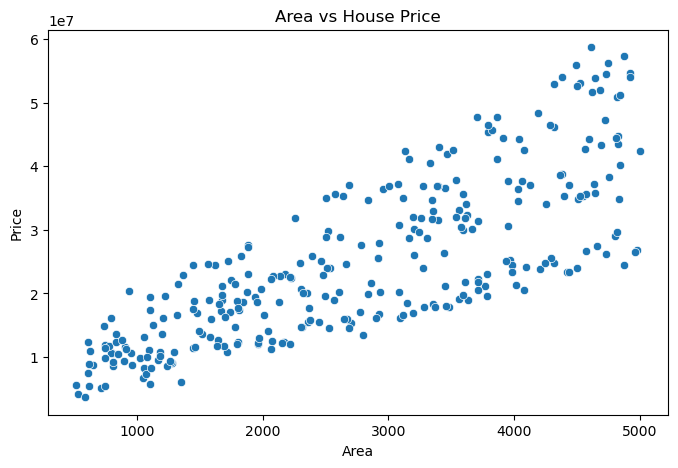

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Area", y="Price")
plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

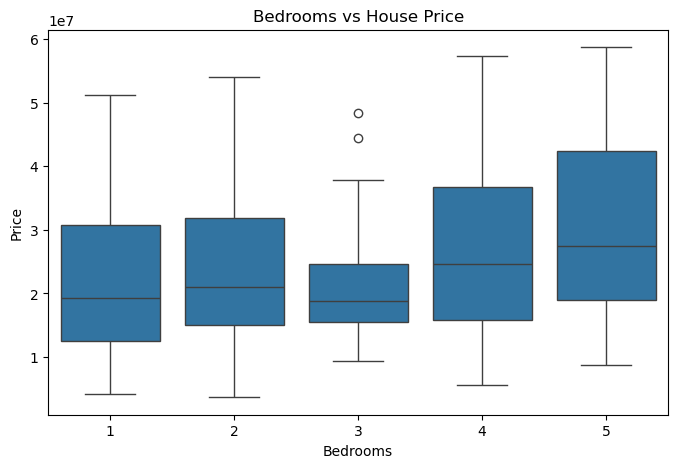

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Bedrooms", y="Price")
plt.title("Bedrooms vs House Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

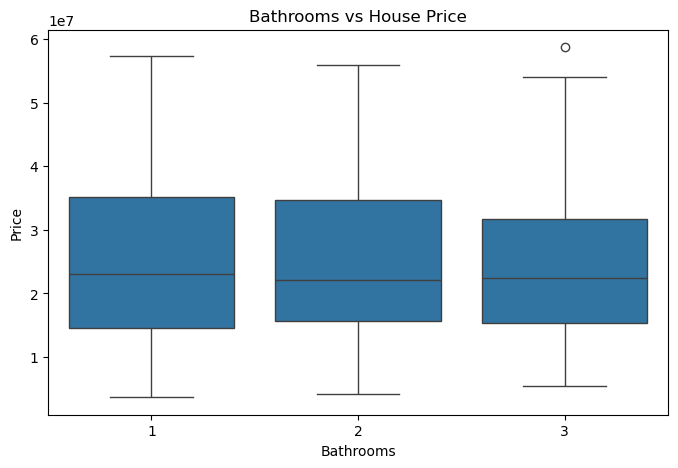

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Bathrooms", y="Price")
plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

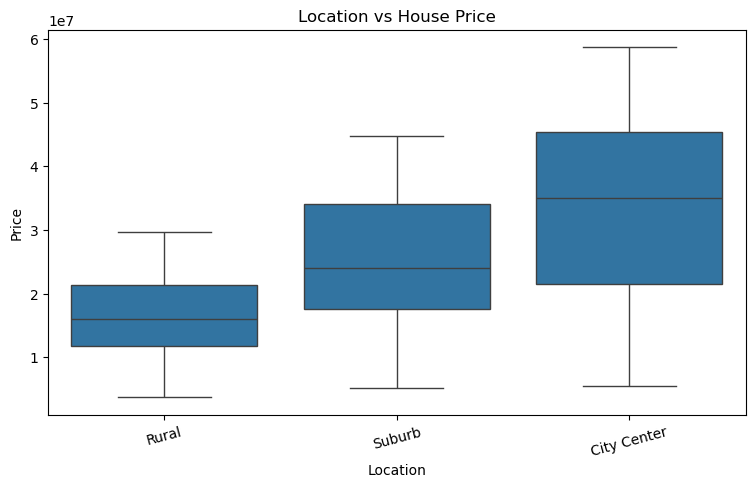

In [7]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Location", y="Price")
plt.title("Location vs House Price")
plt.xlabel("Location")
plt.ylabel("Price")
plt.xticks(rotation=15)
plt.show()

In [8]:
X = df.drop(columns=["Property_ID", "Price"])
y = df["Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Area  Bedrooms  Bathrooms  Age     Location Property_Type
0  3712         4          3   36        Rural         House
1  1591         4          1   35       Suburb         House
2  1646         4          3   20        Rural         Villa
3  4814         1          2   13  City Center         Villa
4   800         4          2   38       Suburb     Apartment

Target:
0    22260000
1    16057500
2    12730000
3    50840000
4    10650000
Name: Price, dtype: int64


In [9]:
print("Location categories:")
print(df["Location"].unique())

print("\nProperty Type categories:")
print(df["Property_Type"].unique())

Location categories:
['Rural' 'Suburb' 'City Center']

Property Type categories:
['House' 'Villa' 'Apartment']


In [10]:
X_encoded = pd.get_dummies(
    X,
    columns=["Location", "Property_Type"],
    drop_first=True
)

print(X_encoded.head())
print("\nColumns:")
print(X_encoded.columns)


   Area  Bedrooms  Bathrooms  Age  Location_Rural  Location_Suburb  \
0  3712         4          3   36            True            False   
1  1591         4          1   35           False             True   
2  1646         4          3   20            True            False   
3  4814         1          2   13           False            False   
4   800         4          2   38           False             True   

   Property_Type_House  Property_Type_Villa  
0                 True                False  
1                 True                False  
2                False                 True  
3                False                 True  
4                False                False  

Columns:
Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location_Rural',
       'Location_Suburb', 'Property_Type_House', 'Property_Type_Villa'],
      dtype='object')


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (240, 8)
Testing data: (60, 8)


In [12]:
X_area = df["Area"].values
y_price = df["Price"].values

x_mean = np.mean(X_area)
y_mean = np.mean(y_price)

m = np.sum((X_area - x_mean) * (y_price - y_mean)) / np.sum((X_area - x_mean) ** 2)

c = y_mean - (m * x_mean)

print("Slope (m):", m)
print("Intercept (c):", c)

Slope (m): 7771.692409121677
Intercept (c): 3436118.7918802425


In [13]:
y_pred_scratch = m * X_area + c

print("First 5 Actual Prices:")
print(y_price[:5])

print("\nFirst 5 Predicted Prices:")
print(y_pred_scratch[:5])


First 5 Actual Prices:
[22260000 16057500 12730000 50840000 10650000]

First 5 Predicted Prices:
[32284641.01453991 15800881.41479283 16228324.49729452 40849046.04939199
  9653472.71917759]


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_price, y_pred_scratch)
mse = mean_squared_error(y_price, y_pred_scratch)
r2 = r2_score(y_price, y_pred_scratch)

print("From-Scratch Linear Regression")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

From-Scratch Linear Regression
MAE: 6114003.32169322
MSE: 58502143723222.23
R² Score: 0.6340733925305242


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
y_pred = model.predict(X_test)

print("Actual Prices:")
print(y_test.head().values)

print("\nPredicted Prices:")
print(y_pred[:5])

Actual Prices:
[ 8930000 18085000 53980000 24800000 21615000]

Predicted Prices:
[15074813.48326404 19163670.53037686 49321254.80756822 27009190.40108807
 21543273.97181161]


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Linear Regression Results
-------------------------
MAE: 2188736.3437038115
MSE: 8454330868276.604
R² Score: 0.9406371185112241


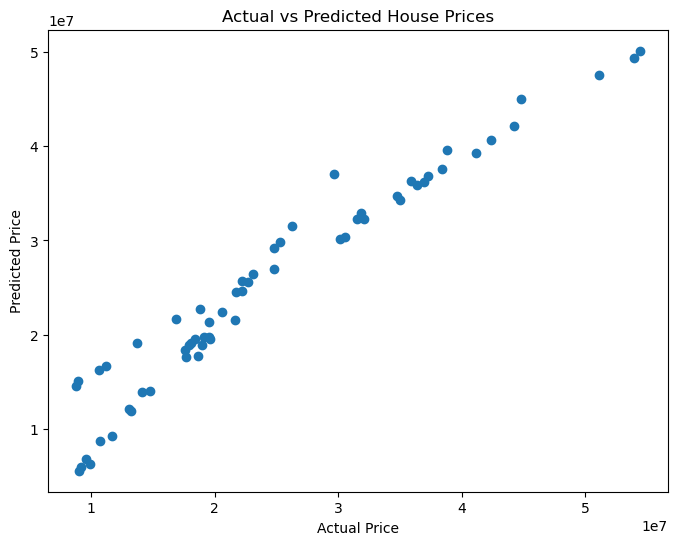

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

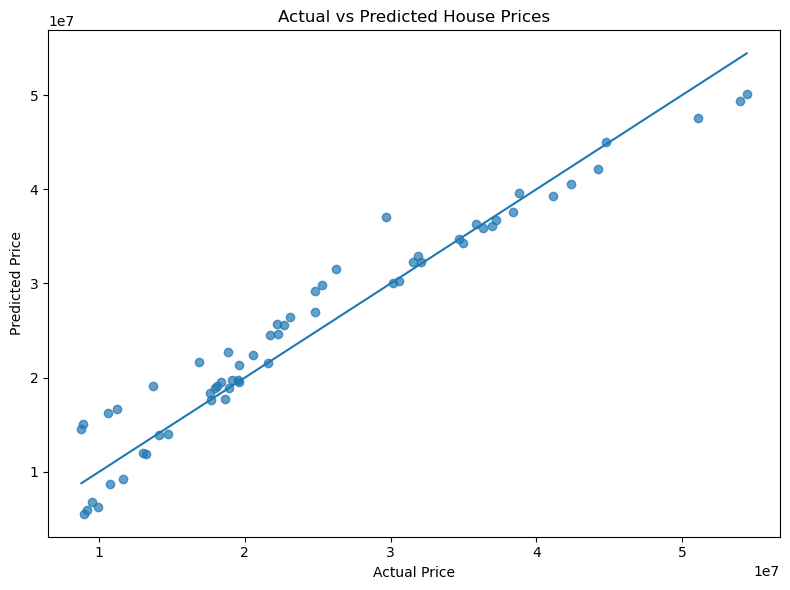

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.tight_layout()

plt.savefig("predictions_vs_actual.png", dpi=300)

plt.show()

In [23]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coefficients)

               Feature   Coefficient
0                 Area  7.558956e+03
1             Bedrooms  1.585709e+06
2            Bathrooms  4.545940e+05
3                  Age -8.244368e+04
4       Location_Rural -1.672813e+07
5      Location_Suburb -8.633012e+06
6  Property_Type_House -6.079037e+05
7  Property_Type_Villa  6.372497e+04


In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("---------------------")
print("MAE:", poly_mae)
print("MSE:", poly_mse)
print("R² Score:", poly_r2)

Polynomial Regression
---------------------
MAE: 7.740144307414691e-05
MSE: 1.1096361491174749e-08
R² Score: 1.0


In [25]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("-------------")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("R² Score:", dt_r2)

Decision Tree
-------------
MAE: 3171747.669460169
MSE: 17225124157246.574
R² Score: 0.8790521662911307


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R² Score:", rf_r2)

Random Forest
-------------
MAE: 1493949.1666666667
MSE: 4120314726645.8335
R² Score: 0.9710688215749718


In [27]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        poly_mae,
        dt_mae,
        rf_mae
    ],
    "MSE": [
        mse,
        poly_mse,
        dt_mse,
        rf_mse
    ],
    "R2 Score": [
        r2,
        poly_r2,
        dt_r2,
        rf_r2
    ]
})

print(results)

                   Model           MAE           MSE  R2 Score
0      Linear Regression  2.188736e+06  8.454331e+12  0.940637
1  Polynomial Regression  7.740144e-05  1.109636e-08  1.000000
2          Decision Tree  3.171748e+06  1.722512e+13  0.879052
3          Random Forest  1.493949e+06  4.120315e+12  0.971069


In [28]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Polynomial Regression
MAE                      0.000077
MSE                           0.0
R2 Score                      1.0
Name: 1, dtype: object


In [29]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
0                 Area    0.693187
4       Location_Rural    0.201724
5      Location_Suburb    0.073616
1             Bedrooms    0.019140
3                  Age    0.008199
2            Bathrooms    0.002207
7  Property_Type_Villa    0.001143
6  Property_Type_House    0.000783


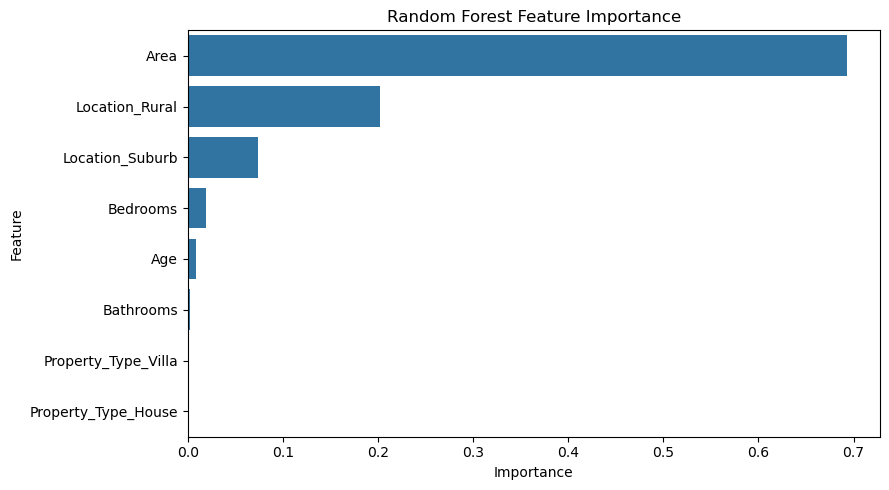

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.show()

In [31]:
results.to_csv("model_results.csv", index=False)

print("Model results saved successfully!")

Model results saved successfully!



### Conclusion:
The House Price Prediction project compared Linear Regression, Polynomial Regression, Decision Tree, and Random Forest models. Random Forest achieved the best practical performance with an R² score of 0.9711 and an MAE of approximately ₹14.94 lakh. Feature importance analysis showed that Area was the most influential feature, followed by Location. The results indicate that house area and location are the major factors affecting house prices in this dataset.